# **Task 3 : Car Price Prediction with Machine Learning**

This notebook presents a complete machine learning workflow for predicting the selling price of used cars based on historical and technical vehicle attributes. The goal is to build a reliable regression model that can estimate car prices by learning patterns from data, similar to the pricing engines used by dealerships, online marketplaces, and automotive analytics platforms.



In [ ]:
## Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Importing/Loading the dataset
from google.colab import files
uploaded = files.upload()
df=pd.read_csv('car data.csv')


Saving car data.csv to car data.csv


In [ ]:
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [ ]:
df.shape

(301, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
## Checking for missing values in each column and getting the sum of them
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [ ]:
## Checking for duplicated values
df.duplicated().sum()

np.int64(2)

In [ ]:
## Drop duplicate values (removing duplicate rows)
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
## checking the distribution of categorical data
print(df['Fuel_Type'].value_counts())
print(df['Selling_type'].value_counts())
print(df['Transmission'].value_counts())

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64
Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


# Data Visualisation

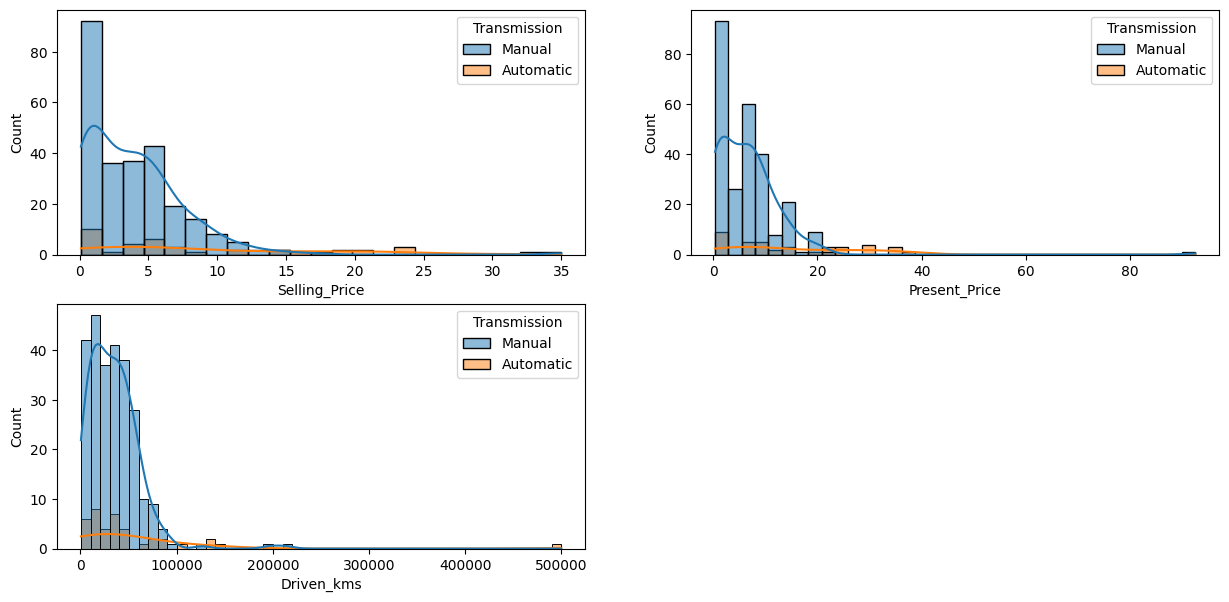

In [ ]:
plt.figure(figsize=(15,7))
for i,col in enumerate(['Selling_Price','Present_Price','Driven_kms']):
    plt.subplot(2,2,i+1)
    sns.histplot(data=df, x=col, kde=True, hue='Transmission')

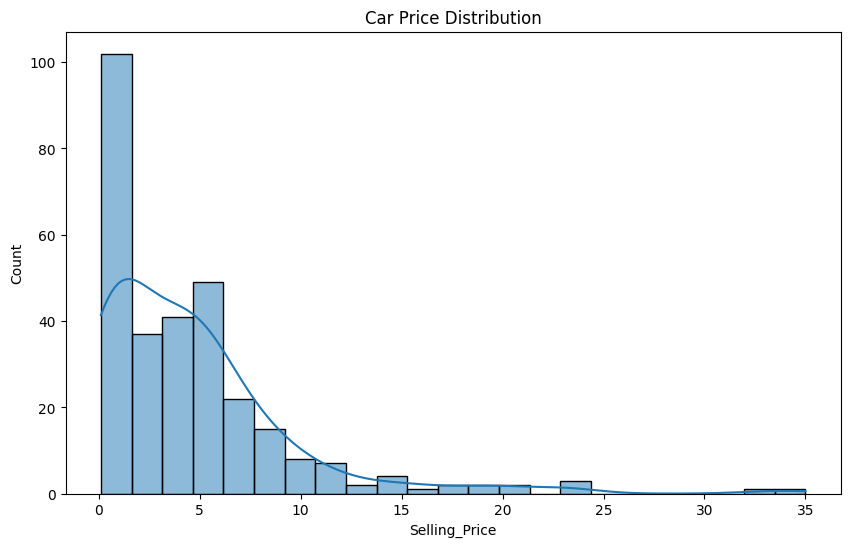

In [ ]:
## Price distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Car Price Distribution')
plt.show()

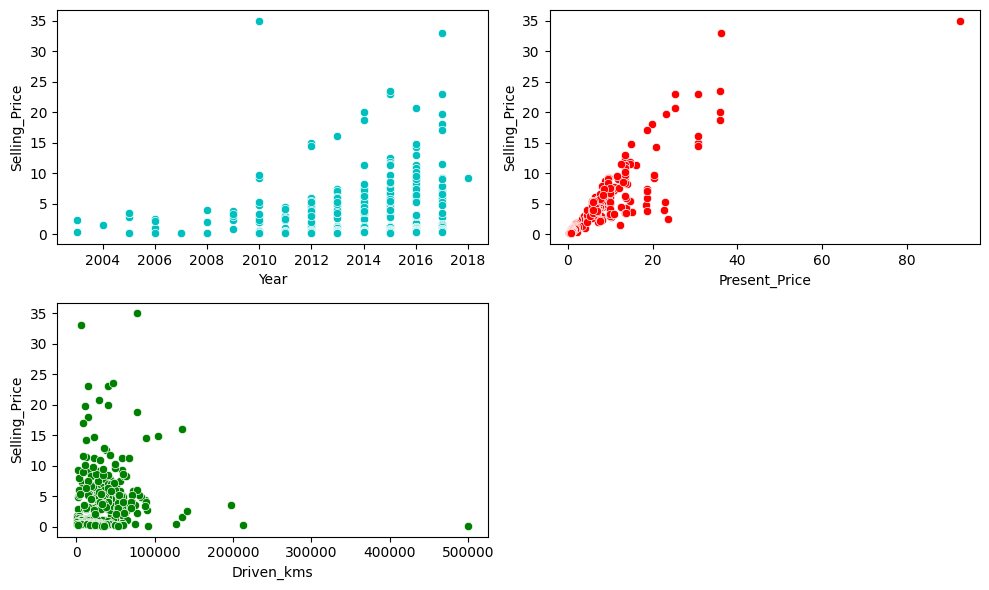

In [ ]:
plt.figure(figsize=(10,6))
color=['c','r','g']
for i,col in enumerate(['Year','Present_Price','Driven_kms']):
    plt.subplot(2,2,i+1)
    sns.scatterplot(df,x=col,y='Selling_Price',color=color[i])
plt.tight_layout()

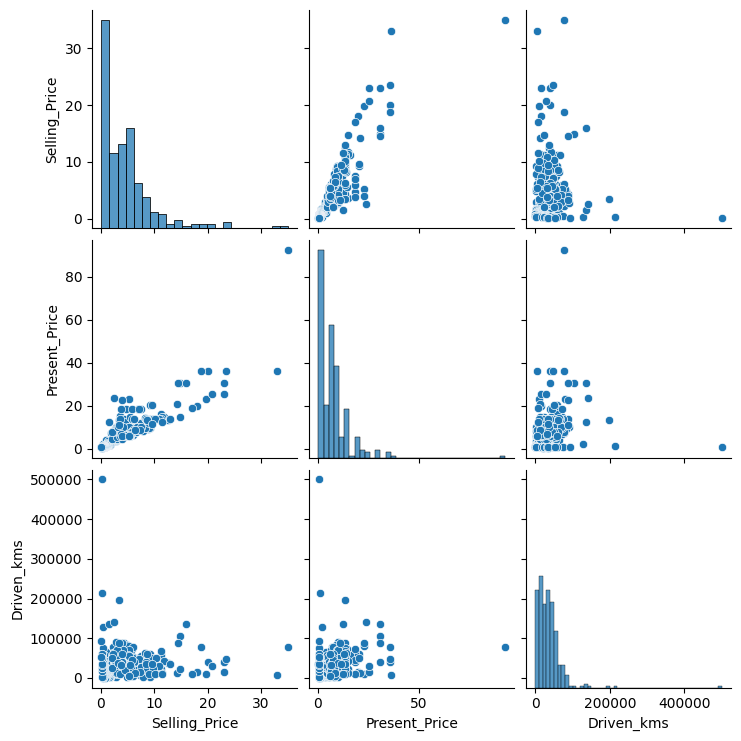

In [ ]:
## Pairplot of numerical features
sns.pairplot(df[['Selling_Price', 'Present_Price', 'Driven_kms']])
plt.show()

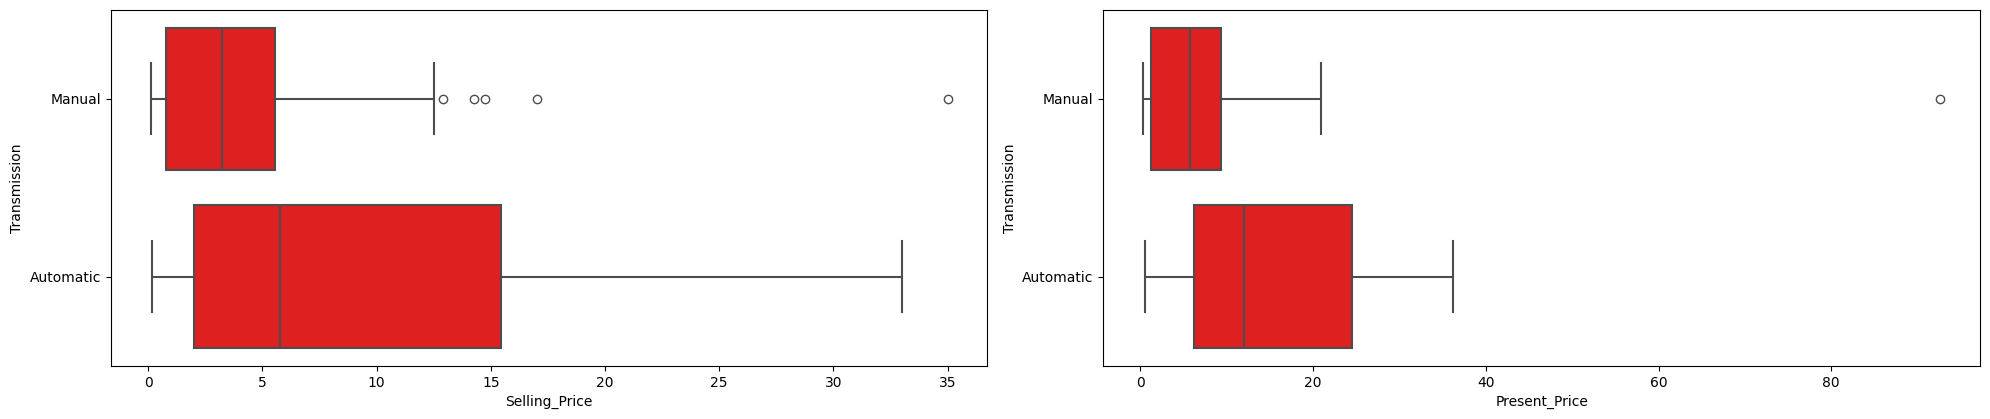

In [ ]:
plt.figure(figsize=(20,8))
for i,col in enumerate(['Selling_Price','Present_Price']):
    plt.subplot(2,2,i+1)
    sns.boxplot(data=df, y='Transmission', x=col, orient='h', color='r', linewidth=1.5)
plt.tight_layout()

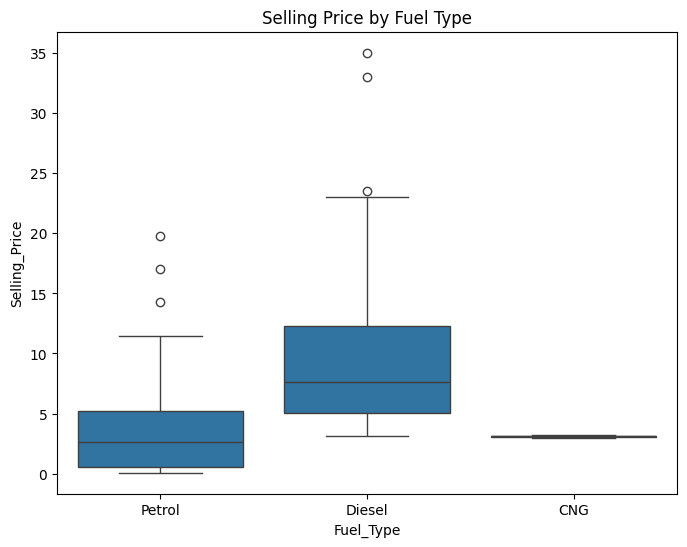

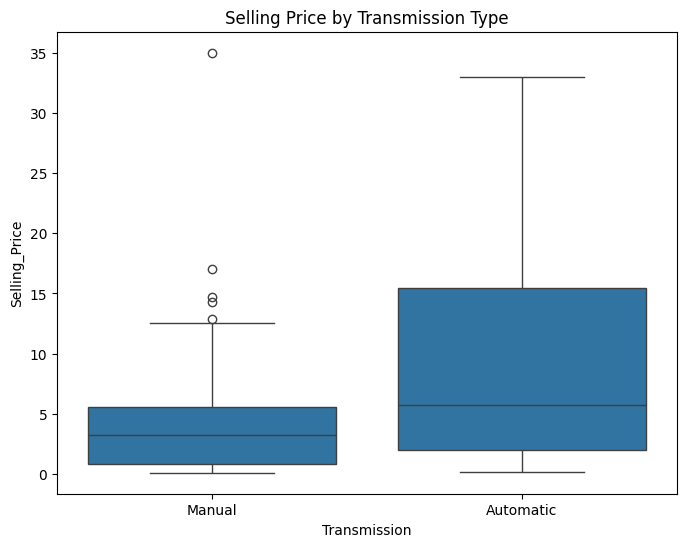

In [ ]:
## Boxplots for categorical features
## Selling Price by Fuel Type
plt.figure(figsize=(8, 6))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title('Selling Price by Fuel Type')
plt.show()

## Selling Price by Transmission Type
plt.figure(figsize=(8, 6))
sns.boxplot(x='Transmission', y='Selling_Price', data=df)
plt.title('Selling Price by Transmission Type')
plt.show()

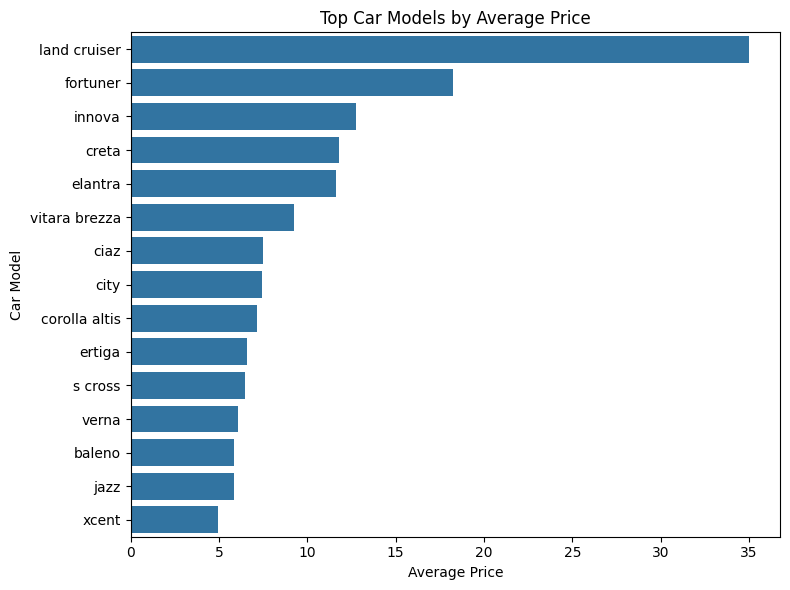

In [ ]:
## Calculating the average price for each car model
avg_prices_by_car = df.groupby('Car_Name')['Selling_Price'].mean().sort_values(ascending=False)

## Plotting the top car models by the average price
Top_car_models = avg_prices_by_car.head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=Top_car_models.values, y=Top_car_models.index)
plt.title('Top Car Models by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()

/tmp/ipykernel_276/4294393780.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fuel_Type', palette='viridis')
/tmp/ipykernel_276/4294393780.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Selling_type', palette='viridis')
/tmp/ipykernel_276/4294393780.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Transmission', palette='viridis')
/tmp/ipykernel_276/4294393780.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

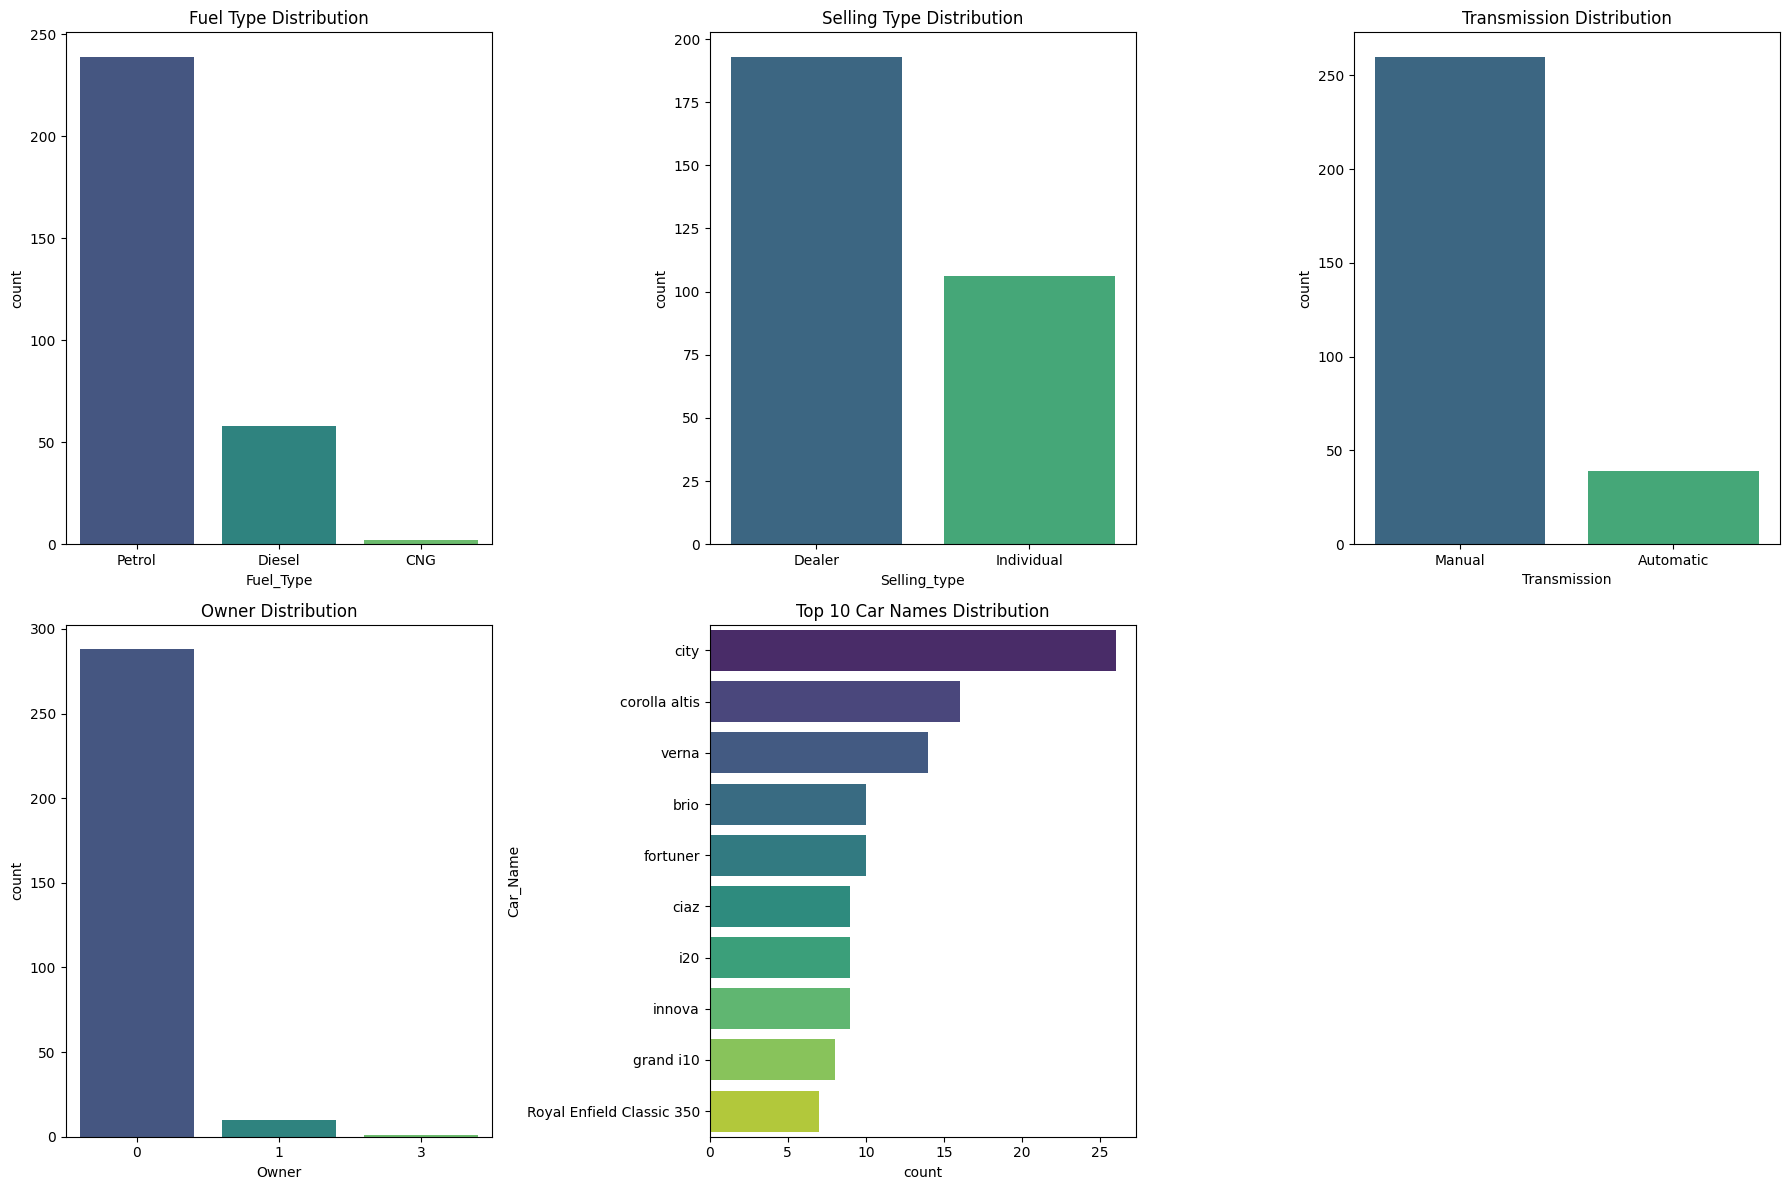

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.countplot(data=df, x='Fuel_Type', palette='viridis')
plt.title('Fuel Type Distribution')

plt.subplot(2, 3, 2)
sns.countplot(data=df, x='Selling_type', palette='viridis')
plt.title('Selling Type Distribution')

plt.subplot(2, 3, 3)
sns.countplot(data=df, x='Transmission', palette='viridis')
plt.title('Transmission Distribution')

plt.subplot(2, 3, 4)
sns.countplot(data=df, x='Owner', palette='viridis')
plt.title('Owner Distribution')

plt.subplot(2, 3, 5)
top_cars = df['Car_Name'].value_counts().head(10).index
sns.countplot(data=df[df['Car_Name'].isin(top_cars)], y='Car_Name', order=top_cars, palette='viridis')
plt.title('Top 10 Car Names Distribution')

plt.tight_layout()
plt.show()

In [ ]:
## encoding "Fuel_Type" Column
df.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)

## encoding "Seller_Type" Column
df.replace({'Selling_type':{'Dealer':0,'Individual':1}},inplace=True)

## encoding "Transmission" Column
df.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipykernel_276/3276008192.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
/tmp/ipykernel_276/3276008192.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Selling_type':{'Dealer':0,'Individual':1}},inplace=True)
/tmp/ipykernel_276/3276008192.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in t

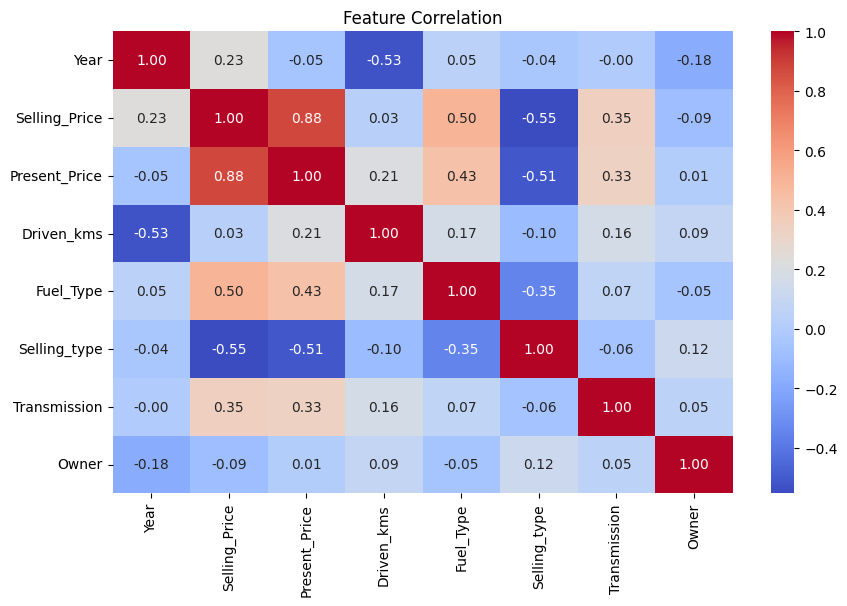

In [ ]:
## Correlation heatmap to understand how these are corre
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm',fmt=".2f")
plt.title('Feature Correlation')
plt.show()

# Data Preprocessing

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0
5,vitara brezza,2018,9.25,9.83,2071,1,0,0,0
6,ciaz,2015,6.75,8.12,18796,0,0,0,0
7,s cross,2015,6.50,8.61,33429,1,0,0,0
8,ciaz,2016,8.75,8.89,20273,1,0,0,0
9,ciaz,2015,7.45,8.92,42367,1,0,0,0


Normalisation and Scalling of the Data

In [ ]:
## This scales the values to have mean = 0 and standard deviation = 1 to better distribution
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Selling_Price','Present_Price','Driven_kms']] = scaler.fit_transform(df[['Selling_Price','Present_Price','Driven_kms']])

df[['Selling_Price','Present_Price','Driven_kms']].head(10)

,Selling_Price,Present_Price,Driven_kms
0,-0.249127,-0.228138,-0.254603
1,0.032229,0.233742,0.156181
2,0.534651,0.269991,-0.770651
3,-0.349612,-0.396520,-0.814297
4,0.002084,-0.078466,0.142061
5,0.936588,0.267653,-0.894631
6,0.434166,0.067699,-0.465233
7,0.383924,0.124996,-0.089545
8,0.836104,0.157737,-0.427312
9,0.574845,0.161245,0.139930


Feature Engineering

In [ ]:
current_year = pd.Timestamp.today().year

## Check if 'Year' column exists before proceeding
if 'Year' in df.columns:
    df['Car_Age'] = current_year - df['Year']
    df.drop(columns=['Year'], inplace=True)
else:
    print("'Year' column not found in DataFrame. 'Car_Age' might already be created or 'Year' dropped.")

In [ ]:
## Handling all the outliers in the data and that we have seen from data visualisation plots
def remove_outliers(col):
    d25=df[col].quantile(0.25)
    d75=df[col].quantile(0.75)
    diqr=d75-d25
    upper_lim=d75+1.5*diqr
    lower_lim=d25-1.5*diqr
    filter_df=df[ (df[col] >= lower_lim) & (df[col] <= upper_lim) ]
    return filter_df

df=remove_outliers('Selling_Price')
df=remove_outliers('Present_Price')
df=remove_outliers('Driven_kms')

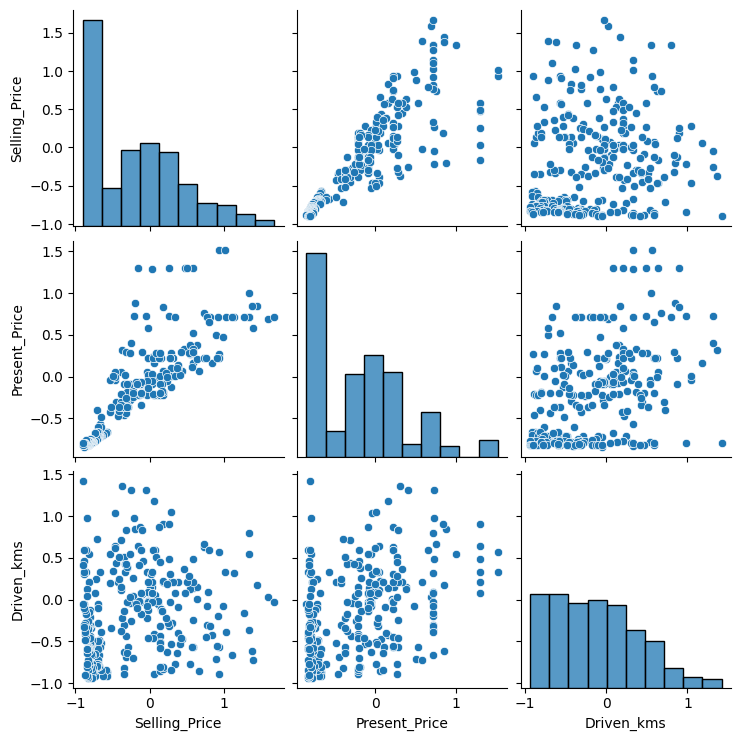

In [ ]:
## Pairplot of numerical features after removing outliers
sns.pairplot(df[['Selling_Price', 'Present_Price', 'Driven_kms']])
plt.show()

In [ ]:
df.head(10)

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,-0.249127,-0.228138,-0.254603,0,0,0,0,12
1,sx4,0.032229,0.233742,0.156181,1,0,0,0,13
2,ciaz,0.534651,0.269991,-0.770651,0,0,0,0,9
3,wagon r,-0.349612,-0.396520,-0.814297,0,0,0,0,15
4,swift,0.002084,-0.078466,0.142061,1,0,0,0,12
5,vitara brezza,0.936588,0.267653,-0.894631,1,0,0,0,8
6,ciaz,0.434166,0.067699,-0.465233,0,0,0,0,11
7,s cross,0.383924,0.124996,-0.089545,1,0,0,0,11
8,ciaz,0.836104,0.157737,-0.427312,1,0,0,0,10
9,ciaz,0.574845,0.161245,0.139930,1,0,0,0,11


**Model Training**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
## Splitting the dataset
X = df.drop(['Car_Name','Selling_Price'],axis=1)
y = df['Selling_Price']

In [ ]:
## Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## First_Model traning
First_Model = DecisionTreeRegressor()
First_Model.fit(X_train, y_train)

## Prediction
y_pred = First_Model.predict(X_test)

## Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R^2-squared (R^2):",r2)

Mean Squared Error (MSE): 0.042054721045908884
R^2-squared (R^2): 0.912244079238686


In [ ]:
from sklearn.ensemble import RandomForestRegressor

## Second_Model training
Second_Model = RandomForestRegressor()
Second_Model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
## Model development
rfr_model=RandomForestRegressor(n_estimators=33,random_state=42)
rfr_model.fit(X_train,y_train)
y_test_pred=rfr_model.predict(X_test)

## MSE
mse=mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error: ",mse)

## R^2 SCORE
r2_sco=r2_score(y_test, y_test_pred)
print("R^2 Score: ",r2_sco)

Mean Squared Error:  0.02515175787141323
R^2 Score:  0.9475156268814149


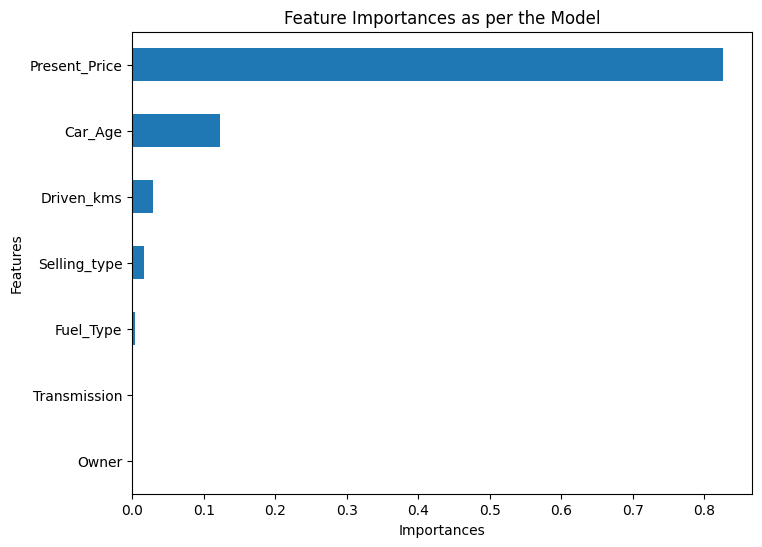

In [ ]:
## Plot feature importance
Important_feat=pd.Series(Second_Model.feature_importances_,index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8,6))
Important_feat.plot(kind='barh')
plt.ylabel('Features')
plt.xlabel('Importances')
plt.title('Feature Importances as per the Model')
plt.show()


Text(0, 0.5, 'Predicted Test Values')

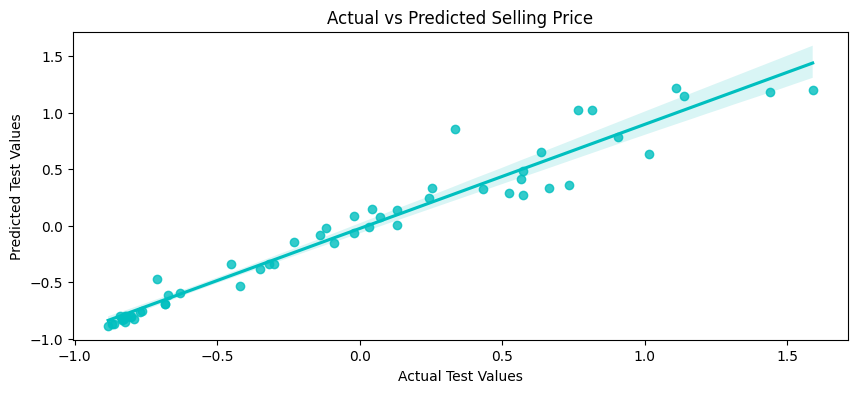

In [ ]:
## RandomForestRegressor Prediction plot visualisation
fig=plt.figure(figsize=(10,4))
sns.regplot(x=y_test,y=y_test_pred,color='c')
plt.title('Actual vs Predicted Selling Price')
plt.xlabel('Actual Test Values')
plt.ylabel('Predicted Test Values')

RandomForestRegressor is the model that gave us a better prediction result and therefore is the model to use for car price prediction.